In [ ]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils import shuffle

from google.colab import drive
drive.mount('/content/drive')

with open('/content/drive/MyDrive/TrafficSign/Dataset/train.p', 'rb') as f:
    train_data = pickle.load(f)
with open('/content/drive/MyDrive/TrafficSign/Dataset/valid.p', 'rb') as f:
    valid_data = pickle.load(f)
with open('/content/drive/MyDrive/TrafficSign/Dataset/test.p', 'rb') as f:
    test_data = pickle.load(f)

X_train, y_train = train_data['features'], train_data['labels']
X_valid, y_valid = valid_data['features'], valid_data['labels']
X_test, y_test = test_data['features'], test_data['labels']

print("Train shape:", X_train.shape)
print("Valid shape:", X_valid.shape)
print("Test shape:", X_test.shape)

signnames = pd.read_csv('/content/drive/MyDrive/TrafficSign/Dataset/signname.csv')
signnames.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train shape: (34799, 32, 32, 3)
Valid shape: (4410, 32, 32, 3)
Test shape: (12630, 32, 32, 3)


,ClassId,SignName
0,0,Speed limit (20km/h)
1,1,Speed limit (30km/h)
2,2,Speed limit (50km/h)
3,3,Speed limit (60km/h)
4,4,Speed limit (70km/h)


Total classes: 43


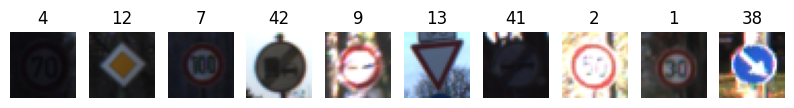

In [ ]:
X_train = X_train / 255.0
X_valid = X_valid / 255.0
X_test = X_test / 255.0


X_train, y_train = shuffle(X_train, y_train)


n_classes = len(np.unique(y_train))
print("Total classes:", n_classes)

plt.figure(figsize=(10, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.axis('off')
    plt.imshow(X_train[i])
    plt.title(y_train[i])
plt.show()


In [ ]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(n_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,627 (920.42 KB)

 Trainable params: 235,627 (920.42 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_valid, y_valid),
    verbose=1
)


Epoch 1/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 56s 99ms/step - accuracy: 0.2861 - loss: 2.6059 - val_accuracy: 0.8163 - val_loss: 0.7086
Epoch 2/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 81s 97ms/step - accuracy: 0.8633 - loss: 0.4360 - val_accuracy: 0.9084 - val_loss: 0.3721
Epoch 3/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 51s 93ms/step - accuracy: 0.9465 - loss: 0.1727 - val_accuracy: 0.9268 - val_loss: 0.2928
Epoch 4/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.9681 - loss: 0.1137 - val_accuracy: 0.9361 - val_loss: 0.2962
Epoch 5/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.9775 - loss: 0.0758 - val_accuracy: 0.9383 - val_loss: 0.2322
Epoch 6/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.9824 - loss: 0.0586 - val_accuracy: 0.9519 - val_loss: 0.2470
Epoch 7/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.9855 - loss: 0.0481 - val_accuracy: 0.9531 - val_loss: 0.1911
Epoch 8/15
544/544 ━━━━━━━━━━━━━━━━━━━━ 51s 94ms/step - accuracy: 0.9873 - loss: 0.0408 - 

Test Accuracy: 0.9453


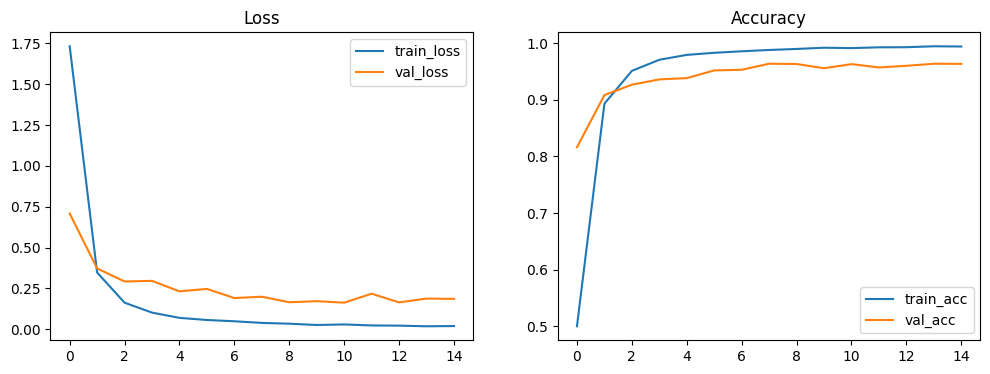

In [ ]:

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Accuracy")
plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


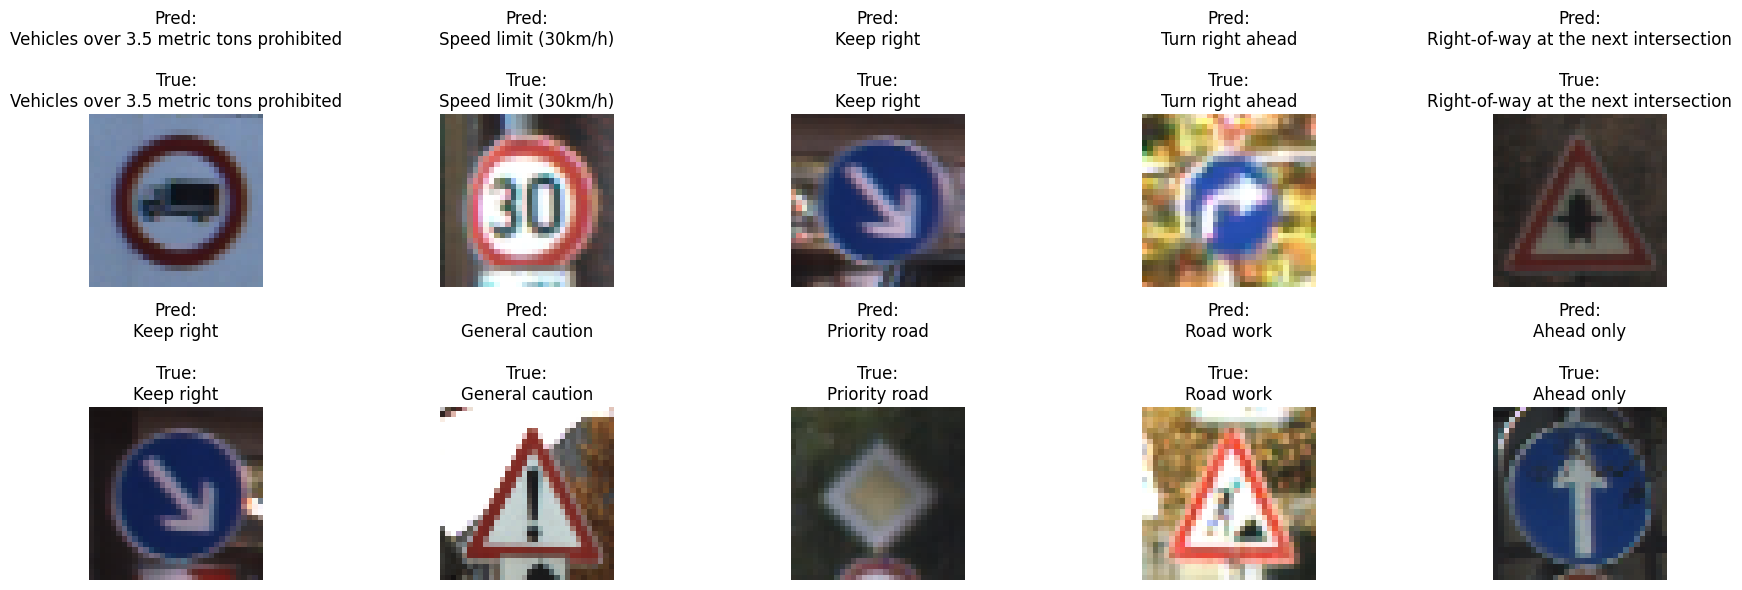

In [ ]:

y_pred = model.predict(X_test[:10])
y_pred_classes = np.argmax(y_pred, axis=1)

plt.figure(figsize=(18,6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[i])
    plt.axis('off')

    pred_label = signnames.loc[signnames['ClassId'] == y_pred_classes[i], 'SignName'].values[0]
    true_label = signnames.loc[signnames['ClassId'] == y_test[i], 'SignName'].values[0]

    plt.title(f"Pred:\n{pred_label}\n\nTrue:\n{true_label}", fontsize=12, pad=5)

plt.tight_layout()
plt.show()
